# MOD 5 - Evaluation e comparazione dei due modelli


## Progetto: Minecraft mob detection
## Autore: Aiman Hamdouni

Qui l'obiettivo è fare un confronto quantitativo completo tra pipeline classica (HOG+SVM) e deep learning (YOLOv5-nano).


## 1. Setup

In [1]:
# GESTIONE E CARICAMENTO LIBRERIE ---------------------------------------------

# kagglehub mi serve per scaricare dataset direttamente da kaggle
# senza doverli scaricare a mano dal sito web
!pip install kagglehub

import kagglehub                      # per scaricare il dataset da kaggle
import cv2                            # OpenCV => per leggere, manipolare e disegnare su immagini
import numpy as np                    # NumPy => le immagini in python sono array numpy (matrici di numeri)
import matplotlib.pyplot as plt       # Matplotlib => per creare grafici e visualizzare immagini
import matplotlib.patches as patches  # patches => per disegnare rettangoli (bounding box) sopra le immagini
from pathlib import Path              # Path => gestisce i percorsi dei file in modo comodo
from collections import Counter       # Counter => conta quante volte appare ogni elemento in una lista
import random                         # per scegliere elementi casuali (servirà per campionare immagini)
import yaml                           # per leggere/scrivere file di configurazione in formato YOLO
import torch                          # PyTorch => il framework di deep learning usato da yolov5
import shutil                         # serve per copiare, spostare e cancellare file e cartelle
import os
import time                           # per misurare i tempi di inferenza
import seaborn as sns                 # per le heatmap della confusion matrix
import pandas as pd                   # per organizzare i dati in tabelle
import re                             # per le espressioni regolari usate nel parsing dell'output di val.py
from collections import defaultdict   # defaultdict => dizionario che crea automaticamente valori di default
from sklearn.svm import LinearSVC     # LinearSVC => il classificatore SVM lineare di scikit
from sklearn.preprocessing import StandardScaler      # normalizza le feature prima di darle all'SVM
from sklearn.model_selection import train_test_split  # per dividere i dati in train e test

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

# GESTIONE CLASSI PER I COLORI -------------------------------------------------

# Definisco le classi, i colori grafici e fisso il seed random

# Fisso il seed per rendere gli esperimenti riproducibili
# così i campionamenti casuali danno sempre lo stesso risultato
random.seed(42)
np.random.seed(42)

# Nomi e colori delle 4 classi di mob riconosciute dal modello,
# usati sia nei grafici che nel disegno delle bounding box
NOMI_CLASSI = {0: "Creeper", 1: "Skeleton", 2: "Spider", 3: "Zombie"}
LISTA_CLASSI = ["Creeper", "Skeleton", "Spider", "Zombie"]
COLORI_CLASSI = ['#2ecc71', '#95a5a6', '#8B4513', '#3498db']

print("LIBRERIE IMPORTATE E SETUP COMPLETTATO\n")

# CARICAMENTO PESI DEL MODELLO YOLO GIA' ADDESTRATO ----------------------------

# Carico i pesi del modello YOLO addestrato nel MOD 4

from google.colab import drive
drive.mount('/content/drive')

cartella_drive = Path('/content/drive/MyDrive/minecraft_mob_detector')
percorso_pesi_yolo = cartella_drive / 'best.pt'

# Controllo che i pesi esistano prima di proseguire
# così evito errori più avanti se il training non è ancora stato fatto
if percorso_pesi_yolo.exists():
    dimensione_mb = percorso_pesi_yolo.stat().st_size / 1e6
    print(f"Pesi YOLO trovatti => {percorso_pesi_yolo}")
    print(f"Dimensionne => {dimensione_mb:.1f} MB")
else:
    print("Pesi non trovati su Drive, ricordda di far partire il file mod 4")

# CARICAMENTO PERCORSI DEL TRAIN E TEST DATASET---------------------------------

percorso_dataset = kagglehub.dataset_download("dracotlw/minecraft-mobs-yolo-dataset")
cartella_dataset = Path(percorso_dataset) / "minecraft_mobs_yolo"

cartella_immagini_train = cartella_dataset / "train" / "images"
cartella_immagini_val   = cartella_dataset / "val"   / "images"
cartella_label_train    = cartella_dataset / "train" / "labels"
cartella_label_val      = cartella_dataset / "val"   / "labels"

# GESTIONE COPIE DELLE CARTELLE IMAGE E LABELS ---------------------------------

# Qui in pratica gestisco la copia della cartella originale del dataset per poter modificarla
# e quindi avere una copia intatta e una copia da modificare
cartella_val_ponte = Path('/content/val_ponte')
cartella_val_ponte.mkdir(parents=True, exist_ok=True)

# In questa cartella ponte metto le images e labels insieme così può attingere YOLO

cartella_immagini_val_scrivibile = cartella_val_ponte / 'images'
if not cartella_immagini_val_scrivibile.exists():
    shutil.copytree(str(cartella_immagini_val), str(cartella_immagini_val_scrivibile))
    print("Immagini di validazione copiate in cartella scrivibile")
else:
    # Evito di ricopiare se il MOD 5 viene rieseguito nella stessa sessione
    print("Cartella immagini scrivibile già presente, salto la copia")

cartella_label_val_scrivibile = cartella_val_ponte / 'labels'
if not cartella_label_val_scrivibile.exists():
    shutil.copytree(str(cartella_label_val), str(cartella_label_val_scrivibile))
    print("Label di validazione copiate in cartela scrivibile")
else:
    print("Cartella label scrivibile già presente, salto la copia")

# Da qui in poi uso i nuovi percorsi scrivibili al posto di quelli originali,
# così il resto del codice lavora sempre sulla struttura images/labels attesa
cartella_immagini_val = cartella_immagini_val_scrivibile
cartella_label_val = cartella_label_val_scrivibile

print("\nVERIFICA SE CI SONO I PERCORSI SALVATTI")
print(cartella_immagini_train)
print(cartella_immagini_val)

# CREAZIONE FUNZIONE PER LA LETTURA DELEL BOUNDING BOX -------------------------

# Definisco la funzione per leggere le bounding box da un file di label YOLO
def leggi_label_yolo(percorso_label):
    lista_box = []
    percorso = Path(percorso_label)
    # Immagine senza mob => nessun file di label, ritorno lista vuota
    if not percorso.exists():
        return lista_box
    contenuto = percorso.read_text().strip()
    if not contenuto:
        return lista_box
    # Ogni riga del file rappresenta una singola bounding box
    # nel formato standard YOLO "classe xc yc larghezza altezza"
    for riga in contenuto.split("\n"):
        parti = riga.strip().split()
        # Scarto righe malformate che non hanno esattamente 5 campi
        if len(parti) == 5:
            classe = int(parti[0])          # indice numerico della classe, 0 = Creeper e così via
            xc = float(parti[1])            # coordinata x del centro box, normalizzata
            yc = float(parti[2])            # coordinata y del centro box, normalizzata
            larghezza = float(parti[3])     # larghezza box, normalizzata rispetto all'immagine
            altezza = float(parti[4])       # altezza box, normalizzata rispetto all'immagine
            lista_box.append((classe, xc, yc, larghezza, altezza))
    return lista_box

LIBRERIE IMPORTATE E SETUP COMPLETTATO

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pesi YOLO trovatti => /content/drive/MyDrive/minecraft_mob_detector/best.pt
Dimensionne => 3.8 MB
Using Colab cache for faster access to the 'minecraft-mobs-yolo-dataset' dataset.
Cartella immagini scrivibile già presente, salto la copia
Cartella label scrivibile già presente, salto la copia

VERIFICA SE CI SONO I PERCORSI SALVATTI
/kaggle/input/minecraft-mobs-yolo-dataset/minecraft_mobs_yolo/train/images
/content/val_ponte/images


## 2. Metriche YOLOv5 => mAP, IoU, Precision, Recall

Riprendiamo brevemente alcune metriche già viste nei mod precedenti, usate per valutare le prestazioni di un modello di object detection come YOLOv5.

- IoU (Intersection over Union) misura quanto il bounding box predetto si sovrappone al bounding box reale, cioè alla ground truth. => IoU = Area di intersezione / Area di unione

Più il valore di IoU è alto, più il box predetto è vicino al box corretto. Di solito, una detection viene considerata corretta se IoU >= 0.5. In questo caso viene contata come True Positive.

- Precision => indica quante delle detection fatte dal modello sono effettivamente corrette. Una precision alta significa che il modello produce pochi falsi positivi.

- Recall => indica quanti oggetti reali presenti nelle immagini sono stati individuati dal modello. Un recall alto significa che il modello riesce a trovare la maggior parte degli oggetti.

- Average Precision (AP) => si calcola ordinando le predizioni in base alla confidence score e osservando come cambiano Precision e Recall al variare della soglia di confidenza. In pratica, AP rappresenta l’area sotto la curva Precision-Recall per una singola classe.

- mAP => (mean Average Precision) riassume la qualità complessiva del modello, facendo la media dell’Average Precision sulle diverse classi.

Le versioni più comuni sono:
- mAP@0.5 => calcolata usando una soglia IoU pari a 0.5. È meno severa.
- mAP@0.5:0.95 => calcolata facendo la media su più soglie IoU, da 0.5 a 0.95. È più severa e segue lo standard COCO.


In [2]:
# VERIFICHIAMO LA PRESENZA DEL FILE DEI PESI OVVERO BEST.PT ----------------------------------------------

# cartella radice di google drive da cui partire la ricercca
cartella_radice_drive = Path('/content/drive/MyDrive')

# cerco tutti i file "best.pt" dentro mydrive, in qualsiasi sottocartella
file_best_trovati = list(cartella_radice_drive.rglob('best.pt'))

# stampo quanti file ho trovato e dove si trovano
print(f"File 'best.pt' trovatti su Drive: {len(file_best_trovati)}")
for f in file_best_trovati:
    dimensione_mb = f.stat().st_size
    print(f"{f}({dimensione_mb:.1f} MB)")

# funzione che restituisce la data di ultima modifica di un file
# mi serve per ordinare i file trovati dal piu' recente al piu' vecchio
def data_modifica(percorso_file):
    return percorso_file.stat().st_mtime

# se ho trovato almeno un file => prendo il piu' recente come sorgente
if len(file_best_trovati) > 0:
    file_best_trovati.sort(key=data_modifica, reverse=True)
    sorgente = file_best_trovati[0]
    print(f"\nUso questo come sorgentte: {sorgente}")
else:
    # nessun file trovato => non posso procedere, blocco tuto
    raise FileNotFoundError(
        "Nessun file 'best.pt' trovato su Google Drive"
        "Controlla di aver completato il training nel MOD 4."
    )

# percorso di destinazione => la cartella standard del proceto
destinazione = Path('/content/drive/MyDrive/minecraft_mob_detector/best.pt')

# a volte puo' capitare che esista una cartella con lo stesso nome del file
# se e' cosi' => la elimino prima di copiare il file vero
if destinazione.exists() and destinazione.is_dir():
    shutil.rmtree(str(destinazione))
    print("Cartela fake eliminata")

# creo la cartella padre se non esiste ancora
destinazione.parent.mkdir(parents=True, exist_ok=True)

# copio il file dei pesi dalla sorgente alla destinazione
# ma solo se sorgente e destinazione non sono gia' lo stesso file
if sorgente.resolve() == destinazione.resolve():
    print("Sorgente e destinazione sono già lo stesso file, copia non necesaria")
else:
    shutil.copy(str(sorgente), str(destinazione))
    print("File copiatto")

# verifico che la copia sia andata a buon fine controllando la dimensione
dimensione_mb = destinazione.stat().st_size
print(f"Copiato: {sorgente} in {destinazione}")
print(f"Verifica: c'è il file? {destinazione.is_file()}, size ={dimensione_mb:.1f} MB")

# aggiorno la variabile percorso_pesi_yolo con il percorso definitivo
percorso_pesi_yolo = Path('/content/drive/MyDrive/minecraft_mob_detector/best.pt')

# stampo un controllo veloce per confermare che tuto sia a posto
print(f"\nPesi: {percorso_pesi_yolo}")
print(f"Esistte: {percorso_pesi_yolo.exists()}")
print(f"E' un file: {percorso_pesi_yolo.is_file()}\n")

# PREPARIAMO L'AMBIENTE PER LA VALIDAZIONE CON YOLO ----------------------------------------------

# Cloniamo il repository ufficiale di YOLOv5 (se non l'abbiamo già fatto) e
# creiamo il file YAML di configurazione del dataset. Questo file dice a YOLOv5 dove
# trovare le immagini, quante classi ci sono e come si chiamano. Poi lanciamo val.py, lo script ufficiale di validazione, che calcola automaticamente
# tutte le metriche standard (Precision, Recall, mAP@0.5, mAP@0.5:0.95) e genera
# la confusion matrix.

# percorso assoluto fisso dove vogliamo che viva il repo yolov5
# (cosi' evitiamo cartelle annidate tipo yolov5/yolov5/yolov5...)
cartella_yolov5_assoluta = '/content/yolov5'

# se la cartella non esiste ancora => la clono da github
if not Path(cartella_yolov5_assoluta).exists():
    print("Cartella yolov5 non trovatta, la clono da GitHub...")
    !git clone -q https://github.com/ultralytics/yolov5.git {cartella_yolov5_assoluta}

    # mi sposto dentro e installo le dipendenze necessarrie
    %cd {cartella_yolov5_assoluta}
    !pip install -q -r requirements.txt
else:
    # la cartella esiste gia' => controllo se sono gia' dentro
    if os.getcwd() != cartella_yolov5_assoluta:
        print("Mi sposto dentro la cartella yolov5 esistentte")
        %cd {cartella_yolov5_assoluta}
    else:
        # sono gia' nella cartella giusta => non serve spostarsi
        print("Sono già dentro la cartela yolov5, nessuno spostamento necessario")

# stampo la cartella attuale per verificca
print(f"\nCartella di lavoro attuale: {os.getcwd()}")

# preparo il dizionario con la configurazione del dataset
# 'path' => cartella radice del dataset
# 'train' => percorso delle immagini di addestramento
# 'val' => percorso delle immagini di validazione
# 'nc' => numero di classi (4 mob)
# 'names' => lista dei nomi delle classi
configurazione_dati = {
    'path': str(cartella_dataset),
    'train': str(cartella_immagini_train),
    'val': str(cartella_immagini_val),
    'nc': 4,
    'names': ['creeper', 'skeleton', 'spider', 'zombie']
}

# scrivo la configurazione in un file yaml
with open('minecraft_mobs.yaml', 'w') as file_yaml:
    yaml.dump(configurazione_dati, file_yaml, default_flow_style=False)
print("File yaml creatto\n")

# PULIZIA LABEL BACKGROUND (4) CHE NON CI SERVONO ----------------------------------------------

# puliamo le label del validation set rimuovendo la classe 4 (background)
cartella_lbl_val_path = Path(cartella_label_val)

# contatore => quante righe di classe 4 abbiamo tolto in totale
righe_rimosse_totale = 0

# .glob('*.txt') trova tutti i file che finiscono con .txt, li scorro uno a uno
for file_lbl in cartella_lbl_val_path.glob('*.txt'):
    # leggo il file e lo divido in righe (una riga = un bounding box)
    righe_originali = file_lbl.read_text().strip().split('\n')
    # tengo solo le righe non vuote che NON iniziano con "4 " (classe background)
    righe_da_tenere = [r for r in righe_originali if r and not r.startswith('4 ')]

    # se ho tolto qualcosa, aggiorno il contatore e riscrivo il file
    if len(righe_da_tenere) != len(righe_originali):
        righe_rimosse_totale += len(righe_originali) - len(righe_da_tenere)
        file_lbl.write_text('\n'.join(righe_da_tenere))

print(f"Annotazioni classe 4 rimose dal validation set: {righe_rimosse_totale}")

# creo la cartella dove val.py salvera' i risultati della validazione
Path('runs/eval').mkdir(parents=True, exist_ok=True)
print("Cartella runs/eval creatta")

File 'best.pt' trovatti su Drive: 2
/content/drive/MyDrive/minecraft_mob_detector/best.pt(3822575.0 MB)
/content/drive/MyDrive/yolov5/yolov5/runs/minecraft/mob_detector/weights/best.pt(3822575.0 MB)

Uso questo come sorgentte: /content/drive/MyDrive/minecraft_mob_detector/best.pt
Sorgente e destinazione sono già lo stesso file, copia non necesaria
Copiato: /content/drive/MyDrive/minecraft_mob_detector/best.pt in /content/drive/MyDrive/minecraft_mob_detector/best.pt
Verifica: c'è il file? True, size =3822575.0 MB

Pesi: /content/drive/MyDrive/minecraft_mob_detector/best.pt
Esistte: True
E' un file: True

Mi sposto dentro la cartella yolov5 esistentte
/content/yolov5

Cartella di lavoro attuale: /content/yolov5
File yaml creatto

Annotazioni classe 4 rimose dal validation set: 152
Cartella runs/eval creatta


In [3]:
# Per la costruzione delle metriche esiste un script val.py di YOLO evitando
# di farlo da 0

# Questi sono parametri messi nel file yaml per la validazione:
# il parametro data => file yaml con la configurazione del dataset
# il parametro weights => percorso dei pesi del modello addestrato
# il parametro img 640 => dimensione delle immagini in input (640x640 pixel)
# il parametro task val => indica che stiamo facendo validazione (non test)
# i parametri project e name => cartella dove salvare i risultati
# il parametro exist ok => se la cartella esiste gia' sovrascrive senza errori
# il parametro verbose => mostra le metriche dettagliate per ogni singola classe
# 2>&1 | tee => salva l'output sia a schermo che nel file di testo

print("Avvio validazione YOLOv5")

!python val.py \
    --data minecraft_mobs.yaml \
    --weights {percorso_pesi_yolo} \
    --img 640 --task val \
    --project runs/eval --name yolo_eval \
    --exist-ok --verbose \
    2>&1 | tee runs/eval/val_output.txt

print("Validazione completata")

Avvio validazione YOLOv5
val: data=minecraft_mobs.yaml, weights=['/content/drive/MyDrive/minecraft_mob_detector/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/eval, name=yolo_eval, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-508-g999e7b66 Python-3.12.13 torch-2.11.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 1764577 parameters, 0 gradients, 4.1 GFLOPs
val: Scanning /root/.cache/kagglehub/datasets/dracotlw/minecraft-mobs-yolo-dataset/versions/5/minecraft_mobs_yolo/val/labels.cache... 517 images, 137 backgrounds, 0 corrupt: 100%|██████████| 517/517 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  18%|█▊        | 3/17 [00:15<01:02,  4.45s/it]Exception in thread Thread-6 (plot_images):
Traceback (most recent call last):
  

In [4]:
# GESTIONE DEL OUPUT CON LE METRICHE

# Leggiamo l'output testuale prodotto da val.py e ne estraiamo le metriche. Ogni
# riga dell'output che contiene metriche ha questo formato: classname  images
# instances  P  R  mAP50  mAP50-95

# P (Precision) => % di detection corrette sul totale predetto
# R (Recall) => % di oggetti reali individuati dal modello
# mAP50 => mean Average Precision con soglia IoU 0.5 (meno severa)
# mAP50-95 => media di mAP su soglie IoU da 0.5 a 0.95 (più severa, standard COCO)

# leggo il file di testo con l'output della validazione
testo_output = Path('runs/eval/val_output.txt').read_text()

# lista vuota dove accumulo le righe di metriche trovate
righe_metriche = []

# scorro ogni riga dell'output
for riga in testo_output.split('\n'):

    # divido la riga in singoli "pezzi" separati da spazi
    # .split() senza argomenti gestisce automaticamente spazi multipli
    # esempio: "   creeper   394   102   0.891" diventa
    # ['creeper', '394', '102', '0.891', ...]
    pezzi = riga.split()

    # una riga valida di metriche ha esattamente 7 pezzi:
    # classe, immagini, istanze, precision, recall, map50, map50_95
    if len(pezzi) != 7:
        continue  # riga diversa (titolo, riga vuota, ecc.) => salto

    # provo a convertire i pezzi nei tipi giusti
    # se la riga non è una riga di metriche (es. e' un log generico)
    # la conversione fallira' e finiamo nel blocco except
    try:
        dati_riga = {
            'Classe':       pezzi[0].capitalize(),
            'Immagini':     int(pezzi[1]),
            'Istanze':      int(pezzi[2]),
            'Precision':    float(pezzi[3]),
            'Recall':       float(pezzi[4]),
            'mAP@0.5':      float(pezzi[5]),
            'mAP@0.5:0.95': float(pezzi[6]),
        }
        righe_metriche.append(dati_riga)
    except ValueError:
        # i pezzi non erano numeri validi => non era una riga di metriche
        continue

# creo un DataFrame pandas con tutte le righe trovate
tabella_metriche = pd.DataFrame(righe_metriche)
print("Metriche YOLOv5-nano (estratte automaticamente):")
print(tabella_metriche.to_string(index=False))

# salvo la tabella come file CSV su Google Drive per consultarla dopo
percorso_csv = Path('/content/drive/MyDrive/minecraft_mob_detector/yolo_metrics.csv')
tabella_metriche.to_csv(str(percorso_csv), index=False)
print(f"\nSalvato: {percorso_csv}")

Metriche YOLOv5-nano (estratte automaticamente):
  Classe  Immagini  Istanze  Precision  Recall  mAP@0.5  mAP@0.5:0.95
     All       517      648      0.745   0.634    0.689         0.508
 Creeper       517      126      0.932   0.770    0.888         0.650
Skeleton       517      188      0.938   0.777    0.821         0.624
  Spider       517      101      0.956   0.871    0.924         0.689
  Zombie       517      201      0.899   0.751    0.812         0.578

Salvato: /content/drive/MyDrive/minecraft_mob_detector/yolo_metrics.csv


Carichiamo il modello YOLOv5 e impostiamo due soglie fondamentali:
- conf = 0.4 => il modello scarta le detection con confidenza inferiore al 40%
  (quelle troppo incerte vengono eliminate)
- iou = 0.45 => se due box si sovrappongono per più del 45%, viene tenuto
  solo quello con confidenza più alta (Non-Maximum Suppression)

In [5]:
# Carico il modello in memoria così posso usarlo per fare predizioni
# senza dover rilanciare ogni volta lo script val.py da riga di comando
# 'custom' => uso pesi miei, non quelli preaddestrati su COCO
# force_reload=True => riscarica il codice YOLOv5, per usare la versione recente
modello_yolo = torch.hub.load('ultralytics/yolov5', 'custom',
                              path=str(percorso_pesi_yolo), force_reload=True)

# Imposto io la soglia di confidenza minima, invece di usare quella di
# default del modello, per decidere quanto essere permissivo, ad esempio
# detection sotto 0.4 vengono scartate perché troppo incerte
modello_yolo.conf = 0.4

# Imposto la soglia IoU per la Non Maximum Suppression, cioè quanto
# due box devono sovrapporsi prima di essere considerate "la stessa
# detection" e quindi tenerne solo una quindi
# se due box si sovrappongono per più del 45% => tengo solo la migliore
modello_yolo.iou = 0.45

print(f"Modello caricato => conf={modello_yolo.conf}, iou={modello_yolo.iou}")

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-7-3 Python-3.12.13 torch-2.11.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 1764577 parameters, 0 gradients, 4.1 GFLOPs
Adding AutoShape... 


Modello caricato => conf=0.4, iou=0.45


## 3. Calcolo manuale di IoU e mAP

Average Precision (AP)
1. Per ogni immagine, confronta ogni predizione con il ground truth
2. Una predizione e' TP se IoU >= 0.5 con un GT box della stessa classe
3. Ordina le predizioni per confidence decrescente
4. Calcola Precision e Recall cumulativi => curva PR
5. AP = area sotto la curva PR

Le funzioni che sono implementate sono:
- calcola_iou => misura quanto due rettangoli si sovrappongono. L'IoU (Intersection over Union) è il rapporto tra l'area di sovrapposizione e l'area totale coperta dai due box. Un IoU di 1.0 significa sovrapposizione perfetta, 0.0 significa nessun contatto.

- calcola_ap => calcola l'Average Precision usando l'interpolazione PASCAL VOC.
Partendo dalla curva Precision/Recall, si applica una correzione monotona
(ogni punto di precision viene alzato al massimo dei punti successivi)
e poi si calcola l'area sotto la curva risultante.

- valuta_yolo_su_validazione => esegue la pipeline completa di evaluation.
Per ogni immagine del validation set fa la detection, confronta ogni predizione
con i ground truth, decide se è un True Positive o un False Positive,
e infine calcola l'AP per ogni classe e il mAP globale.

In [6]:

# GESTIONE FUNZIONE IOU -------------------------------------------------------
# l'IoU dice "quanto due rettangoli si sovrappongono".
# Formula: IoU = area_intersezione / area_unione
# Se i due box coincidono perfettamente => IoU = 1.0
# Se non si toccano per niente => IoU = 0.0

# Ogni box è rappresentato come [x1, y1, x2, y2]:
#   (x1, y1) = angolo IN ALTO A SINISTRA
#   (x2, y2) = angolo IN BASSO A DESTRA

def calcola_iou(box1, box2):

    # PASSO 1 => trovo il rettangolo di intersezione
    # L'intersezione tra due rettangoli è ANCH'ESSA un rettangolo.
    # Per trovarlo? prendo il punto più "interno" tra i due box.
    x_sinistra = max(box1[0], box2[0])   # il bordo sinistro più a destra dei due
    y_alto = max(box1[1], box2[1])       # il bordo alto più in basso dei due
    x_destra = min(box1[2], box2[2])     # il bordo destro più a sinistra dei due
    y_basso = min(box1[3], box2[3])      # il bordo basso più in alto dei due

    # PASSO 2=> calcolo larghezza e altezza dell'intersezione
    # Se i box NON si sovrappongono, x_destra-x_sinistra (o l'altezza)
    # risulterebbe negativo quindi con max(0, ...) lo "blocco" a zero,
    # così l'area di intersezione diventa 0 invece di un numero negativo senza senso.
    larghezza_inter = max(0, x_destra - x_sinistra)
    altezza_inter = max(0, y_basso - y_alto)
    area_intersezione = larghezza_inter * altezza_inter

    # PASSO 3 => area dei due box presi singolarmente
    # area = base * altezza, dove base = x2-x1 e altezza = y2-y1
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # PASSO 4 => area dell'unione
    # Unione = (area box1 + area box2) - intersezione.
    # Sottraggo l'intersezione perché altrimenti la conterei due volte
    # (una volta dentro area_box1, una volta dentro area_box2).
    # nel caso limite (teorico) in cui l'unione fosse 0.
    area_unione = area_box1 + area_box2 - area_intersezione

    # PASSO 5=> il rapporto finale
    return area_intersezione / area_unione

# GESTIONE FUNZIONE AP (AVERAGE PRECISION) -------------------------------------------------------

# l'AP è "l'area sotto la curva Precision-Recall".
# Una curva PR alta e larga = il modello trova quasi tutti gli
# oggetti (recall alto) rimanendo preciso (precision alta).
# Qui uso il metodo standard, che si fa in due fasi:
#   1) Lisciare la curva (interpolazione monotona)
#   2) Sommare l'area sotto la curva lisciata, a rettangoli
def calcola_ap(valori_precision, valori_recall):

    # PASSO 1 => aggiungo due punti "di cornice" alla curva
    # All'inizio della curva (recall=0) forzo precision=0.
    # Alla fine (recall=1) forzo anche lì precision=0.
    # Questo serve solo per chiudere la curva ed evitare casi limite
    # quando calcolo l'area senza questi punti il calcolo
    # potrebbe saltare il primo o l'ultimo tratto.
    prec = np.concatenate([[0], valori_precision, [0]])
    rec = np.concatenate([[0], valori_recall, [1]])

    # PASSO 2 => interpolazione monotona
    # La curva PR grezza è a zig-zag (sale e scende in continuazione).
    # La regola dice che per ogni punto, la precision diventa
    # il massimo valore di precision raggiunto a quel recall o a recall MAGGIORI.
    # In pratica scorro la curva da destra (recall alto) verso sinistra (recall basso)
    # e ogni volta tengo il valore più alto visto finora.
    # Risultato è una curva a scalini sempre decrescente (o uguale), molto più stabile.

    # Riassunto chiaro: la curva precision-recall grezza sale e scende in modo irregolare (man mano che abbassi la soglia
    # di confidenza, ogni tanto la precision risale per caso). La convenzione PASCAL VOC dice che, a un dato
    # livello di recall, la precision ufficiale da considerare è la massima raggiungibile a quel recall o a un
    # recall più alto, questo rende il calcolo dell'area sotto la curva (l'AP) più stabile e meno sensibile al
    # rumore statistico delle singole predizioni. Per questo serve scorrere da destra (recall alti) verso sinistra
    # (recall bassi) dove ogni punto "eredita" il massimo di tutto quello che viene dopo di lui.

    # Esempio semplice:
    # Prendi prec = [0.3, 0.5, 0.4, 0.1] (4 elementi, indici 0-3).
    # Il ciclo parte da i = 2 (cioè len(prec)-2 = 2) e scende fino a i = 0:
    # i=2: prec[2] = max(prec[2], prec[3]) = max(0.4, 0.1) = 0.4 => array: [0.3, 0.5, 0.4, 0.1] (non cambia, 0.4 era già più grande di 0.1)
    # i=1: prec[1] = max(prec[1], prec[2]) = max(0.5, 0.4) = 0.5 => array: [0.3, 0.5, 0.4, 0.1] (non cambia, 0.5 era già più grande di 0.4)
    # i=0: prec[0] = max(prec[0], prec[1]) = max(0.3, 0.5) = 0.5 => array finale: [0.5, 0.5, 0.4, 0.1] (qui cambia: 0.3 viene sostituito da 0.5)

    for i in range(len(prec) - 2, -1, -1):
        prec[i] = max(prec[i], prec[i + 1])

    # PASSO 3 => trovo dove il recall "cambia valore"
    # L'area sotto la curva si calcola sommando tanti rettangolini.
    # Ogni rettangolino serve solo nei punti in cui il recall si è mosso
    # rispetto al punto precedente (altrimenti larghezza = 0, niente da sommare).

    # Questo ciclo serve a trovare i punti in cui il valore di recall cambia rispetto al punto precedente, e a salvarne l'indice in indici_cambio.

    # Esempio semplice:
    # Immagina rec = [0.0, 0.2, 0.2, 0.5, 0.5, 0.5, 1.0] (7 elementi, indici 0-6).
    # Il ciclo scorre i da 1 a 6:
    # i=1: rec[1]=0.2 vs rec[0]=0.0 => diversi => aggiungo 1
    # i=2: rec[2]=0.2 vs rec[1]=0.2 => uguali => non aggiungo nulla
    # i=3: rec[3]=0.5 vs rec[2]=0.2 => diversi => aggiungo 3
    # i=4: rec[4]=0.5 vs rec[3]=0.5 => uguali => non aggiungo nulla
    # i=5: rec[5]=0.5 vs rec[4]=0.5 => uguali => non aggiungo nulla
    # i=6: rec[6]=1.0 vs rec[5]=0.5 => diversi => aggiungo 6
    # indici_cambio = [1, 3, 6]

    # Riassunto chiaro: Nella formula dell'AP, l'area sotto la curva PR si calcola sommando tanti rettangolini,
    # uno per ogni "salto" di recall. Se il recall resta fermo da un punto al successivo
    # (come tra i=1 e i=2, entrambi 0.2), quel tratto avrebbe base zero, un rettangolo
    # con base zero ha area zero, quindi non c'è motivo di calcolarlo. Questo ciclo
    # serve proprio a saltare in anticipo quei punti "inutili" e a tenere solo le
    # posizioni dove c'è davvero un pezzo di area da sommare nel passo successivo

    indici_cambio = []
    for i in range(1, len(rec)):
        if rec[i] != rec[i - 1]:
            indici_cambio.append(i)

    # PASSO 4 => sommo i rettangolini
    # Ogni rettangolino ha:
    #   base = quanto è cresciuto il recall (rec[i] - rec[i-1])
    #   altezza = la precision in quel punto

    area = 0.0
    for i in indici_cambio:
        base = rec[i] - rec[i - 1]
        altezza = prec[i]
        area += base * altezza

    return float(area)


# GESTIONE FUNZIONE CONVERSIONE GROUND TRUTH (predizione mob reale) A FORMATO YOLO (NORMALIZZATO 0 A 1) -------------------------------------------------------

# Il file .txt di YOLO salva ogni box come classe, x_centro, y_centro,
# larghezza, altezza => tutti valori normalizzati tra 0 e 1
# (cioè "percentuale" rispetto alla dimensione dell'immagine).
# A noi però serve il formato [x1, y1, x2, y2] in pixel, lo stesso
# usato da calcola_iou. Questa funzione fa solo questa conversione.

def converti_gt_in_pixel(box_gt_raw, larghezza_img, altezza_img):

    gt_per_classe = defaultdict(list)

    for box in box_gt_raw:
        classe_id, xc, yc, bw, bh = box

        # da centro+larghezza/altezza => angoli opposti del rettangolo
        x1 = (xc - bw / 2) * larghezza_img
        y1 = (yc - bh / 2) * altezza_img
        x2 = (xc + bw / 2) * larghezza_img
        y2 = (yc + bh / 2) * altezza_img

        gt_per_classe[classe_id].append([x1, y1, x2, y2])

    return gt_per_classe


# GESTIONE FUNZIONE TRESHOLD TP E FP -------------------------------------------------------

def assegna_tp_fp(predizioni, gt_per_classe, num_classi, soglia_iou=0.5):

    # Per ogni predizione decide se è un vero positivo (TP) o un falso
    # positivo (FP), confrontandola con i ground truth della stessa classe.
    # Una predizione è TP solo se il suo IoU con un GT supera la soglia
    # E quel GT non è già stato assegnato a una predizione più sicura
    # (altrimenti due box sullo stesso mob conterebbero entrambi come corretti).
    # Ritorna una lista di tuple (classe, confidenza, è_tp).

    risultati = []
    gt_matchati = defaultdict(set)  # GT già "usati", per classe

    # Valuto prima le predizioni più sicure, hanno sempre la priorità
    # sul match rispetto a quelle meno sicure
    def prendi_confidenza(predizione):
        # la confidenza è il quinto valore di ogni predizione (indice 4)
        return predizione[4]
    predizioni_ordinate = sorted(predizioni, key=prendi_confidenza, reverse=True)

    for pred in predizioni_ordinate:
        x1, y1, x2, y2, conf, cls = pred[0], pred[1], pred[2], pred[3], pred[4], int(pred[5])

        if cls >= num_classi:
            continue  # classe non valida (es. indice fuori range), la ignoro

        # Cerco, tra i GT della stessa classe, quello con IoU più alto
        miglior_iou = 0
        miglior_indice = -1
        # gt_per_classe[cls] =>  è la lista di tutti i box ground truth di quella classe specifica (es. tutti gli Skeleton presenti nell'immagine)
        for gi, gt_box in enumerate(gt_per_classe[cls]):
            iou = calcola_iou([x1, y1, x2, y2], gt_box)
            if iou > miglior_iou:
                miglior_iou = iou
                miglior_indice = gi

        # Due condizioni devono essere entrambe vere perché sia un TP (vero positivo):
        # 1) il miglior IoU trovato supera la soglia (es. 0.5) => la sovrapposizione è abbastanza buona
        # 2) quel ground truth non è già stato assegnato a un'altra predizione prima
        #    (altrimenti lo stesso mob reale conterebbe come "trovato" due volte)
        e_tp = (miglior_iou >= soglia_iou) and (miglior_indice not in gt_matchati[cls])

        # Se è un vero positivo, "blocco" quel ground truth aggiungendolo all'insieme
        # dei già usati, così le predizioni successive (meno sicure) non potranno
        # più rivendicarlo come proprio
        if e_tp:
            gt_matchati[cls].add(miglior_indice)

        risultati.append((cls, float(conf), int(e_tp)))

    return risultati


# GESTIONE FUNZIONE AP PER CLASSE (DA TP/FP A PRECISION, RECALL, AP) -------------------------------------------------------

def calcola_ap_per_classe(tutte_predizioni, contatore_gt, num_classi=4):
    # Per ogni classe di mob, trasforma la lista di TP/FP (accumulata su
    # tutte le immagini) in un punteggio unico AP (Average Precision).
    # Ritorna un dizionario ad esempio {0: 0.88, 1: 0.82, 2: 0.92, 3: 0.81}
    ap_per_classe = {}

    for cls in range(num_classi):
        pred_classe = tutte_predizioni[cls]  # tutte le predizioni fatte per questa classe
        n_gt = contatore_gt[cls]             # quanti mob reali di questa classe esistono in totale

        # Se non ci sono predizioni o non esistono mob reali di questa classe,
        # non ha senso calcolare un AP => metto 0.0 ed esco da questo giro
        if len(pred_classe) == 0 or n_gt == 0:
            ap_per_classe[cls] = 0.0
            continue

        # Riordino le predizioni dalla più sicura alla meno sicura
        # (deve essere lo stesso ordine usato prima in assegna_tp_fp)
        pred_classe = sorted(pred_classe, reverse=True)

        flag_tp = [p[1] for p in pred_classe]   # lista di 1 (TP) e 0 (FP), una per predizione
        flag_fp = [1 - t for t in flag_tp]      # l'opposto: 1 dove prima c'era 0, e viceversa

        # np.cumsum fa una somma "progressiva" quindi ogni elemento è la somma
        # di tutti quelli fino a lì. Esempio: [1,0,1,1] => cumsum = [1,1,2,3]
        # Così al passo i sappiamo quanti TP/FP abbiamo visto considerando
        # tutte le predizioni più sicure fino a quel punto
        tp_cumulativo = np.cumsum(flag_tp)
        fp_cumulativo = np.cumsum(flag_fp)

        # Precision = delle detection fatte finora, quante percento sono giuste?
        precision = tp_cumulativo / (tp_cumulativo + fp_cumulativo + 1e-6)

        # Recall = dei mob reali totali, quanti ne abbiamo trovati finora?
        recall = tp_cumulativo / (n_gt + 1e-6)

        # Precision e recall, punto per punto, disegnano la curva PR
        # calcola_ap ne misura l'area sotto la curva => un singolo numero (AP)
        ap_per_classe[cls] = calcola_ap(precision, recall)

    return ap_per_classe # quindi per ogni classe di mob ritorno AP per classe, es: creeper => ap = 0.88

# GESTIONE FUNZIONE PRINCIPALE DI VALUTAZIONE -------------------------------------------------------

def valuta_yolo_su_validazione(modello, cartella_img, cartella_lbl, soglia_iou=0.5, num_classi=4):

    # Funzione che scorre tutte le immagini di validazione, e per
    # ognuna chiama in ordine le funzioni sopra (leggi label, converti GT,
    # fai detection, assegna TP/FP). Alla fine calcola l'AP per classe e
    # il mAP@0.5 complessivo.
    # Ritorna (ap_per_classe, map50, tutte_predizioni, contatore_gt).

    # ap_per_classe => dizionario con l'AP di ogni classe, es. {0: 0.888, 1: 0.821, ...}
    # map50 => un solo numero, la media dei 4 AP (il mAP@0.5 finale) (media delle AP di tutte le classi)
    # tutte_predizioni => tutte le predizioni fatte, con confidenza e TP/FP, divise per classe (usate dopo per disegnare le curve Precision-Recall)
    # contatore_gt => quanti mob reali c'erano in totale per ogni classe


    # Due contenitori vuoti che riempirò via via, scorrendo tutte le immagini.
    # defaultdict evita di dover controllare "esiste già questa classe?"
    # prima di aggiungere un valore
    tutte_predizioni = defaultdict(list)   # per classe=> lista di (confidenza, controllo se è TP)
    contatore_gt = defaultdict(int)        # per classe=> quanti mob reali esistono in totale

    # Prendo la lista di tutti i file immagine (.jpg e .png) da validare
    lista_immagini = sorted(list(cartella_img.glob("*.jpg")) + list(cartella_img.glob("*.png")))

    # Ripeto tutto il processo qui sotto per ogni singola immagine del validation set
    for file_immagine in lista_immagini:

        # Il file di label ha lo stesso nome dell'immagine, ma estensione .txt
        # (es. screenshot_042.jpg => screenshot_042.txt)
        file_label = cartella_lbl / (file_immagine.stem + ".txt")
        box_gt_raw = leggi_label_yolo(file_label)

        # Carico l'immagine. OpenCV la legge in formato BGR di default,
        # ma il modello YOLO si aspetta RGB, quindi la converto
        immagine_bgr = cv2.imread(str(file_immagine))
        if immagine_bgr is None:
            continue  # immagine corrotta o illeggibile, la salto e proseguo
        altezza, larghezza = immagine_bgr.shape[:2]
        immagine_rgb = cv2.cvtColor(immagine_bgr, cv2.COLOR_BGR2RGB)

        # Converto i ground truth dal formato YOLO (normalizzato) ai pixel,
        # e sommo quanti mob reali di ogni classe ci sono in questa immagine
        # al totale generale (mi servirà dopo per calcolare il recall)
        gt_per_classe = converti_gt_in_pixel(box_gt_raw, larghezza, altezza)
        for cls, lista_box in gt_per_classe.items():
            contatore_gt[cls] += len(lista_box)
        # Esempio ciclo:
        # gt_per_classe = {
        #   0: [[10,20,50,80], [120,30,180,90]],   # classe 0 (Creeper) => 2 box
        #   3: [[200,40,260,100]]                   # classe 3 (Zombie) => 1 box
        # }

        # Faccio girare il modello sull'immagine per ottenere le predizioni
        risultati = modello(immagine_rgb)
        # .xyxy => formato dei box: x1,y1 angolo alto-sinistra, x2,y2 angolo basso-destra
        # [0] => prendo i risultati della prima (e unica) immagine passata al modello
        # .cpu() => sposto i dati dalla GPU alla CPU, se erano lì
        # .numpy() => converto da tensore PyTorch ad array NumPy
        predizioni = risultati.xyxy[0].cpu().numpy()  # ogni riga: x1,y1,x2,y2,conf,classe

        # Confronto ogni predizione con i ground truth di questa immagine,
        # per capire quali sono corrette (TP) e quali sbagliate (FP)
        esiti = assegna_tp_fp(predizioni, gt_per_classe, num_classi, soglia_iou)

        # Aggiungo questi risultati al contenitore globale. Immagine dopo
        # immagine, tutte_predizioni finisce per contenere i dati di
        # tutto il validation set, non solo di questa singola immagine
        for cls, conf, e_tp in esiti:
            tutte_predizioni[cls].append((conf, e_tp))

    # Solo adesso, con le predizioni di TUTTE le immagini raccolte insieme,
    # ha senso calcolare l'AP per classe e la loro media (il mAP@0.5 finale)
    ap_per_classe = calcola_ap_per_classe(tutte_predizioni, contatore_gt, num_classi)
    map50 = float(np.mean([ap_per_classe[c] for c in range(num_classi)]))

    return ap_per_classe, map50, tutte_predizioni, contatore_gt

Eseguiamo la funzione di evaluation su tutto il validation set, quindi per ogni immagine il modello fa le detection, poi confrontiamo ogni box predetto
con i ground truth per decidere se è un TP o un FP. Alla fine otteniamo l'AP
per ciascuna delle 4 classi e il mAP@0.5 globale.

In [7]:
# lancio la valutazione completa sul validation set
print("Calcolo metriche YOLO sul validation set")
ap_yolo, map50_yolo, pred_yolo, gt_cnt_yolo = valuta_yolo_su_validazione(
    modello_yolo, cartella_immagini_val, cartella_label_val
)

# stampo l'AP per ogni singola classe
print("\nAP per classe (mAP@0.5):")
for classe_id in range(4):
    nome = NOMI_CLASSI[classe_id]
    valore_ap = ap_yolo[classe_id]
    print(f"   {nome:<10}  AP = {valore_ap:.4f}")

# stampo il mAP globale (media degli AP)
print(f"\nmAP@0.5 = {map50_yolo:.4f}")

Calcolo metriche YOLO sul validation set

AP per classe (mAP@0.5):
   Creeper     AP = 0.7646
   Skeleton    AP = 0.7713
   Spider      AP = 0.8559
   Zombie      AP = 0.7555

mAP@0.5 = 0.7868


## 4. Re-training HOG+SVM e metriche equivalenti

Riaddestriamo rapidamente HOG+SVM e calcoliamo le stesse metriche per il confronto diretto.

Per fare un confronto equo tra i due approcci, riaddestriamo la pipeline classica HOG + SVM* sullo stesso dataset.

Il processo è:
1. Estrarre crop (ritagli) delle regioni dove ci sono i mob (positivi)
   e di regioni di sfondo (negativi)
2. Calcolare il descrittore HOG (Histogram of Oriented Gradients) per ogni crop,
   che trasforma l'immagine in un vettore numerico di feature
3. Addestrare un classificatore SVM lineare su queste feature
4. Valutare Precision, Recall e F1 sulle stesse classi

In [8]:
import cv2

# definisco la dimensione della finestra HOG in pixel (larghezza, altezza)
# tutti i crop verranno ridimensionati a 64x128 prima di calcolare le feature HOG
DIMENSIONE_FINESTRA = (64, 128)

# creo il descrittore HOG di OpenCV con i parametri standard
# primo parametro => dimensione finestra di analisi
# secondo parametro => dimensione dei blocchi in cui si raggruppa l'immagine
# terzo parametro => passo con cui i blocchi si spostano (stride)
# quarto parametro => dimensione delle celle all'interno dei blocchi
# quinto parametro => numero di orientamenti del gradiente (bin dell'istogramma)
descrittore_hog = cv2.HOGDescriptor(DIMENSIONE_FINESTRA, (16, 16), (8, 8), (8, 8), 9)

def estrai_crop_per_training(cartella_img, cartella_lbl, max_per_classe=200):
    # Estrae crop positivi (mob) e negativi (sfondo) dal dataset.

    # liste dove accumulo i crop e le etichette
    crop_positivi = []       # qui metto i ritagli dei mob
    etichette_positivi = []  # qui metto la classe di ogni crop positivo
    crop_negativi = []       # qui metto i ritagli di sfondo (senza mob)

    # contatore per sapere quanti crop ho gia' estratto per ogni classe
    # serve a bilanciare il dataset => non voglio troppi crop di una sola classe
    contatore = Counter()

    # raccolgo tutti i file immagine dal dataset
    lista_jpg = sorted(list(cartella_img.glob("*.jpg")))
    lista_png = sorted(list(cartella_img.glob("*.png")))
    lista_immagini = lista_jpg + lista_png

    # scorro ogni immagine del dataset
    for file_img in lista_immagini:

        # cerco il file label corrispondente a questa immagine
        file_lbl = cartella_lbl / (file_img.stem + ".txt")
        box_trovati = leggi_label_yolo(file_lbl)

        # carico l'immagine con OpenCV
        immagine = cv2.imread(str(file_img))
        if immagine is None:
            continue
        altezza, larghezza = immagine.shape[:2]

        # converto in scala di grigi (HOG lavora su immagini in grigio)
        grigio = cv2.cvtColor(immagine, cv2.COLOR_BGR2GRAY)

        # applico l'equalizzazione dell'istogramma per migliorare il contrasto
        grigio = cv2.equalizeHist(grigio)

        # se l'immagine non ha annotazioni => la uso come esempio negativo (sfondo)
        if len(box_trovati) == 0:
            tw, th = DIMENSIONE_FINESTRA
            # l'immagine deve essere almeno grande quanto la finestra HOG
            if larghezza >= tw and altezza >= th:
                # prendo un ritaglio casuale della dimensione giusta
                x = random.randint(0, larghezza - tw)
                y = random.randint(0, altezza - th)
                crop_neg = grigio[y:y+th, x:x+tw]
                crop_negativi.append(crop_neg)
            continue

        # se l'immagine ha annotazioni => per ogni box estraggo un crop positivo
        for box in box_trovati:
            classe_id, xc, yc, bw, bh = box

            # se ho gia' raggiunto il limite per questa classe => salto
            if contatore[classe_id] >= max_per_classe:
                continue

            # converto le coordinate normalizzate YOLO in coordinate pixel
            x1 = max(0, int((xc - bw / 2) * larghezza))
            y1 = max(0, int((yc - bh / 2) * altezza))
            x2 = min(larghezza, int((xc + bw / 2) * larghezza))
            y2 = min(altezza, int((yc + bh / 2) * altezza))

            # se il ritaglio e' troppo piccolo (meno di 10px) => lo scarto
            if x2 - x1 < 10 or y2 - y1 < 10:
                continue

            # ritaglio la regione del mob e la ridimensiono alla finestra HOG
            crop = cv2.resize(grigio[y1:y2, x1:x2], DIMENSIONE_FINESTRA)
            crop_positivi.append(crop)
            etichette_positivi.append(classe_id)
            contatore[classe_id] += 1

            # data augmentation => specchio il crop orizzontalmente
            # questo raddoppia i dati e rende il modello piu' robusto
            if contatore[classe_id] < max_per_classe:
                crop_flippato = cv2.flip(crop, 1)
                crop_positivi.append(crop_flippato)
                etichette_positivi.append(classe_id)
                contatore[classe_id] += 1

    # bilancio il numero di negativi con quello dei positivi
    # troppi negativi farebbero sbilanciare il training
    crop_negativi = crop_negativi[:len(crop_positivi)]

    return crop_positivi, etichette_positivi, crop_negativi
# estraggo i crop positivi e negativi dal training set
print("Preparazione dati HOG+SVM")
crop_pos, etichette_pos, crop_neg = estrai_crop_per_training(
    cartella_immagini_train, cartella_label_train
)
print(f"Crop positivi: {len(crop_pos)}, Crop negativi: {len(crop_neg)}")

# calcolo il descrittore HOG per ogni crop positivo
# trasformo ogni immagine in un vettore numerico di feature
feature_positivi = []
for crop in crop_pos:
    feat = descrittore_hog.compute(crop).flatten()
    feature_positivi.append(feat)
feature_positivi = np.array(feature_positivi, dtype=np.float32)

# stessa cosa per i crop negativi
feature_negativi = []
for crop in crop_neg:
    feat = descrittore_hog.compute(crop).flatten()
    feature_negativi.append(feat)
feature_negativi = np.array(feature_negativi, dtype=np.float32)

# unisco positivi e negativi in un unico dataset
# X contiene tutte le feature, y contiene le etichette
X = np.vstack([feature_positivi, feature_negativi])

# le etichette dei negativi sono 4 (background)
# le etichette dei positivi sono 0,1,2,3 (le 4 classi di mob)
y = np.concatenate([etichette_pos, np.full(len(crop_neg), 4)])

print(f"Dataset totale: {X.shape[0]} campioni, {X.shape[1]} feature")

Preparazione dati HOG+SVM
Crop positivi: 1000, Crop negativi: 488
Dataset totale: 1488 campioni, 3780 feature


Addestriamo il classificatore SVM lineare sulle feature HOG. Prima di passare i dati alla SVM, applichiamo lo tandardScaler che normalizza ogni feature a media zero e varianza unitaria. Questo è fondamentale per le SVM,
che sono sensibili alla scala delle feature.

Calcoliamo poi le metriche di classificazione (Precision, Recall, F1)
solo sulle 4 classi mob (escludendo il background) per un confronto equo con YOLO.

In [9]:
# divido il dataset in 75% training e 25% test
# stratify=y garantisce che la proporzione delle classi sia mantenuta in entrambi i set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# normalizzo le feature => media 0 e varianza 1
# fit_transform sul training => impara media e deviazione standard
# transform sul test => applica la stessa normalizzazione (senza ricalcolare)
normalizzatore = StandardScaler()
X_train_norm = normalizzatore.fit_transform(X_train)
X_test_norm = normalizzatore.transform(X_test)

# creo e addestro il classificatore SVM lineare
# C=1.0 => parametro di regolarizzazione (bilancia errori vs semplicita')

# C alto (es. 100) => penalizza molto gli errori: la SVM cerca di
# classificare bene anche i punti scomodi, margine più stretto,
# confine più "contorto" => rischio overfitting
# C basso (es. 0.01) => tollera più errori pur di avere un margine
# ampio e un confine più semplice => rischio underfitting

# C=1.0 è il valore di default, un compromesso neutro tra i due estremi
# max_iter=10000 => numero massimo di iterazioni per convergere
classificatore_svm = LinearSVC(C=1.0, max_iter=10000, random_state=42)
classificatore_svm.fit(X_train_norm, y_train)

# faccio le predizioni sul test set
predizioni_svm = classificatore_svm.predict(X_test_norm)

# calcolo l'accuratezza complessiva (tutte le classi incluso background)
accuratezza_svm = accuracy_score(y_test, predizioni_svm)
print(f"HOG+SVM accuracy: {accuratezza_svm:.4f}")

# per il confronto con YOLO calcolo le metriche solo sulle classi mob (0,1,2,3)
# escludo la classe 4 (background) perche' YOLO non ha una classe background esplicita
maschera_mob = y_test < 4
y_test_mob = y_test[maschera_mob]
pred_mob = predizioni_svm[maschera_mob]

# precision macro => media della precision calcolata su ogni classe separatamente
prec_svm = precision_score(y_test_mob, pred_mob, average='macro', zero_division=0)

# recall macro => media della recall calcolata su ogni classe separatamente
rec_svm = recall_score(y_test_mob, pred_mob, average='macro', zero_division=0)

# F1 macro => media armonica tra precision e recall, calcolata per classe
f1_svm = f1_score(y_test_mob, pred_mob, average='macro', zero_division=0)

print(f"Precision macro: {prec_svm:.4f}")
print(f"Recall macro: {rec_svm:.4f}")
print(f"F1 macro: {f1_svm:.4f}")

HOG+SVM accuracy: 0.7930
Precision macro: 0.6752
Recall macro: 0.6000
F1 macro: 0.6342


## 5. Precision-Recall Curves per classe
Ogni punto della curva corrisponde a un diverso confidence threshold.
- Threshold alto => alta precision, bassa recall.
- Threshold basso => bassa precision, alta recall.
AP (Area under PR curve) riassume la performance a tutti i threshold.
E' la metrica piu' informativa per detection con classi sbilanciate.

Le curve Precision vs Recall ci mostrano come si comporta YOLO al variare
della soglia di confidenza.

Andando da sinistra a destra sul grafico (recall crescente) stiamo abbassando la soglia, cioè accettando anche detection meno sicure. Questo fa salire il recall
(troviamo più oggetti) ma tipicamente abbassa la precision (più falsi positivi).

L'area sotto la curva (AP) riassume in un singolo numero la qualità
della detection per quella classe. Più è alta, meglio è.

In [15]:
# creo una griglia 2x2 di grafici, uno per ogni classe di mob
fig, assi = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Precision-Recall Curves con YOLOv5-nano per classe",
             fontsize=16, fontweight='bold')
# scorro le 4 classi
for classe_id in range(4):
    # scelgo il sottografico giusto nella griglia 2x2
    riga = classe_id // 2
    colonna = classe_id % 2
    ax = assi[riga, colonna]
    # prendo le predizioni salvate per questa classe
    pred_classe = pred_yolo[classe_id]
    n_gt = gt_cnt_yolo[classe_id]
    # se non ci sono dati per questa classe => scrivo un messaggio e passo oltre
    if len(pred_classe) == 0 or n_gt == 0:
        ax.set_title(f"{NOMI_CLASSI[classe_id]} => nessun dato")
        continue
    # ordino le predizioni per confidenza decrescente
    pred_classe.sort(reverse=True)
    # estraggo i flag TP/FP
    lista_tp = []
    for p in pred_classe:
        lista_tp.append(p[1])
    # calcolo TP cumulativi
    tp_cum = np.cumsum(lista_tp)
    # calcolo FP cumulativi (ogni predizione e' o TP o FP)
    lista_fp = []
    for t in lista_tp:
        lista_fp.append(1 - t)
    fp_cum = np.cumsum(lista_fp)
    # calcolo precision e recall ad ogni step
    precision = tp_cum / (tp_cum + fp_cum + 1e-6)
    recall = tp_cum / (n_gt + 1e-6)
    # calcolo l'AP (area sotto la curva PR) per questa classe
    ap = calcola_ap(precision, recall)
    # disegno la curva PR con il colore della classe
    ax.plot(recall, precision, color=COLORI_CLASSI[classe_id], linewidth=2)
    # coloro l'area sotto la curva con trasparenza
    ax.fill_between(recall, precision, alpha=0.15, color=COLORI_CLASSI[classe_id])
    # imposto titolo ed etichette degli assi
    ax.set_title(f"{NOMI_CLASSI[classe_id]} con AP = {ap:.3f}", fontweight='bold')
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)
    # scrivo il numero di GT boxes nell'angolo del grafico
    ax.text(0.05, 0.1, f"GT boxes: {n_gt}", transform=ax.transAxes, fontsize=10)

plt.tight_layout()

# salvo il grafico su Google Drive
plt.savefig(str(cartella_drive / 'pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato su Drive: pr_curves.png")

Grafico salvato su Drive: pr_curves.png


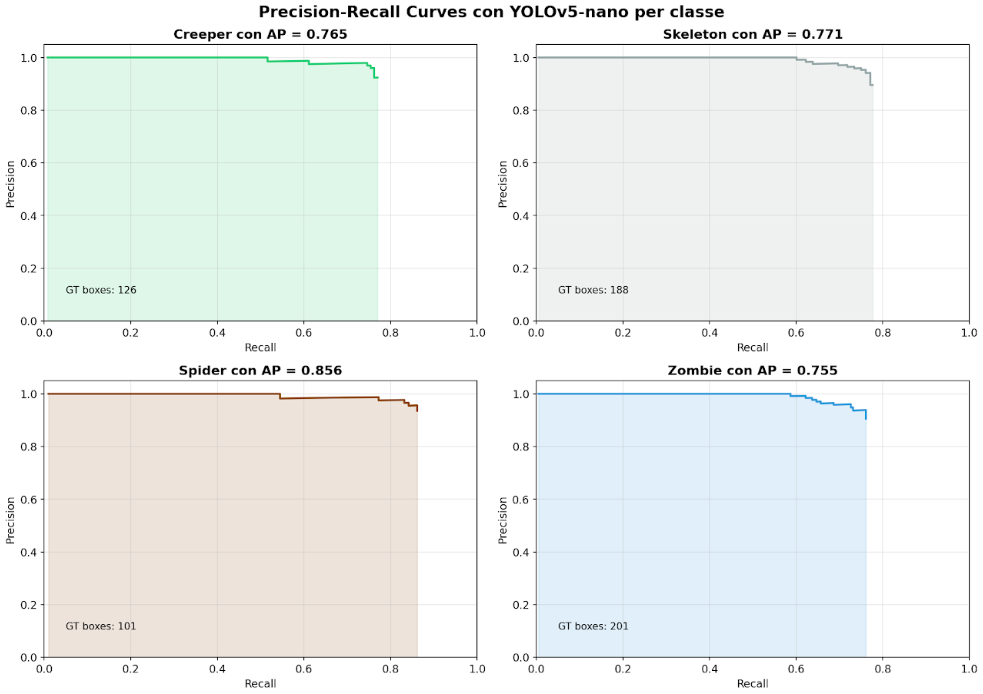

All'inizio il modello è quasi perfetto (precision vicina al 100%), poi a un certo punto cede e comincia a sbagliare di più.
Il numero più importante da guardare è l'AP, che riassume tutto il grafico in un solo voto da 0 a 1:

- Spider: 0.856 => il mob che il modello riconosce meglio
- Skeleton: 0.771
- Creeper: 0.765
- Zombie: 0.755 => il mob che il modello riconosce peggio

Sono comunque tutti voti buoni, vicini tra loro (tra 0.75 e 0.86), non c'è un mob che il modello proprio non capisce, ma Spider gli riesce un filo meglio e Zombie un filo peggio.

Un altro dettaglio da notare, nessun grafico arriva fino in fondo a destra (recall = 1.0). Significa che, per ogni mob, c'è una piccola parte di casi  che il modello non trova mai. Probabilmente sono i mob più piccoli, nascosti o mescolati con lo sfondo.

## 6. Tabella comparativa finale

Misuriamo la velocità di inferenza di entrambi i modelli per completare il confronto.

Per YOLO misuriamo il tempo su un'immagine intera (640×640), facendo 15 ripetizioni e scartando le prime due (warm-up della GPU).

Per HOG+SVM misuriamo il tempo su un singolo crop (64×128), che è l'unità base
di inferenza. In un'applicazione reale servirebbero migliaia di crop per coprire
l'intera immagine con sliding window, quindi il tempo effettivo sarebbe molto più alto.

Il grafico a barre mostra l'AP di YOLO per ogni classe, con la linea rossa
che indica il mAP medio. Ci fa capire se ci sono classi più facili o più difficili.

In [29]:
# carico un'immagine di test dal validation set per misurare i tempi
lista_file_val = list(cartella_immagini_val.glob("*.jpg"))
immagine_test_bgr = cv2.imread(str(lista_file_val[0]))
immagine_test_rgb = cv2.cvtColor(immagine_test_bgr, cv2.COLOR_BGR2RGB)

# misuro il tempo di inferenza YOLO su 15 ripetizioni
tempi_yolo = []
for i in range(15):
    inizio = time.time()
    _ = modello_yolo(immagine_test_rgb)
    fine = time.time()
    tempi_yolo.append(fine - inizio)

# scarto le prime 2 misurazioni (warm up) e calcolo la media
tempo_yolo_ms = np.mean(tempi_yolo[2:]) * 1000

# misuro il tempo di inferenza HOG+SVM su 50 crop singoli
tempi_svm = []
for i in range(min(50, len(crop_pos))):
    inizio = time.time()
    # per ogni crop => calcolo HOG, normalizzo, classifico
    feat = descrittore_hog.compute(crop_pos[i]).flatten().reshape(1, -1)
    feat_norm = normalizzatore.transform(feat)
    classificatore_svm.predict(feat_norm)
    fine = time.time()
    tempi_svm.append(fine - inizio)

# calcolo la media dei tempi SVM
tempo_svm_ms = np.mean(tempi_svm) * 1000

# per YOLO prendo precision e recall dalla riga "All" di val.py
riga_all = tabella_metriche[tabella_metriche['Classe'] == 'All'].iloc[0]
prec_yolo = float(riga_all['Precision'])
rec_yolo  = float(riga_all['Recall'])
# F1 = media armonica di precision e recall
f1_yolo   = 2 * prec_yolo * rec_yolo / (prec_yolo + rec_yolo)

confronto = pd.DataFrame(
    {
        'HOG+SVM':     [prec_svm, rec_svm, f1_svm, np.nan],
        'YOLOv5-nano': [prec_yolo, rec_yolo, f1_yolo, map50_yolo],
    },
    index=['Precision', 'Recall', 'F1', 'mAP@0.5'],
).round(3)

print("Metriche di qualita'")
print(confronto.to_string(na_rep='--'))
print("\nP/R/F1 SVM = classificazione su crop; YOLO = detection su immagine intera")
print("mAP@0.5 esiste solo per YOLO (l'SVM non fa detection)")

pratica = pd.DataFrame(
    {
        'HOG+SVM':     [f"{tempo_svm_ms:.1f} ms/crop", "No"],
        'YOLOv5-nano': [f"{tempo_yolo_ms:.1f} ms/img", "Si"],
    },
    index=['Inferenza', 'GPU richiesta'],
)

print("\nLato pratico")
print(pratica.to_string())

# creo una figura con due grafici affiancati
fig, assi = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle("HOG+SVM vs YOLOv5-nano => confronto quantitativo", fontsize=15, fontweight='bold')

# GRAFICO 1 => AP di YOLO per ogni classe

# raccolgo i valori AP delle 4 classi
valori_ap = [ap_yolo[i] for i in range(4)]

# disegno le barre con i colori delle classi
barre = assi[0].bar(LISTA_CLASSI, valori_ap, color=COLORI_CLASSI, edgecolor='black')

# linea orizzontale per il mAP medio
assi[0].axhline(map50_yolo, color='red', linestyle='--', label=f'mAP@0.5 = {map50_yolo:.3f}')
assi[0].set_ylabel("Average Precision")
assi[0].set_ylim([0, 1])
assi[0].set_title("YOLOv5-nano => AP per classe")
assi[0].legend()
assi[0].grid(True, alpha=0.3, axis='y')

# scrivo il valore sopra ogni barra
for barra, valore in zip(barre, valori_ap):
    assi[0].text(barra.get_x() + barra.get_width() / 2, valore + 0.01,
                 f'{valore:.3f}', ha='center', fontsize=10, fontweight='bold')

# GRAFICO 2 => Precision, Recall, F1 dei due modelli

# uso i numeri veri gia' calcolati per l'SVM le metriche macro,
# per YOLO le metriche aggregate della riga "All"
metriche_nomi = ['Precision', 'Recall', 'F1']
valori_svm  = [prec_svm, rec_svm, f1_svm]
valori_yolo = [prec_yolo, rec_yolo, f1_yolo]

x = np.arange(len(metriche_nomi))   # posizione dei gruppi sull'asse x
larghezza = 0.35                    # larghezza di ogni barra

barre_svm  = assi[1].bar(x - larghezza/2, valori_svm,  larghezza,
                         label='HOG+SVM', color='#3498db', edgecolor='black')
barre_yolo = assi[1].bar(x + larghezza/2, valori_yolo, larghezza,
                         label='YOLOv5-nano', color='#e74c3c', edgecolor='black')

assi[1].set_ylabel("Valore (0-1)")
assi[1].set_ylim([0, 1])
assi[1].set_xticks(x)
assi[1].set_xticklabels(metriche_nomi)
assi[1].set_title("Confronto diretto: Precision, Recall, F1")
assi[1].legend()
assi[1].grid(True, alpha=0.3, axis='y')

# scrivo il valore sopra ogni barra dei due gruppi
for gruppo in (barre_svm, barre_yolo):
    for barra in gruppo:
        h = barra.get_height()
        assi[1].text(barra.get_x() + barra.get_width() / 2, h + 0.01,
                     f'{h:.2f}', ha='center', fontsize=9)

plt.tight_layout()

# salvo il grafico comparativo su Drive
plt.savefig(str(cartella_drive / 'comparison_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato: comparison_plot.png")

Metriche di qualita'
           HOG+SVM  YOLOv5-nano
Precision    0.675        0.745
Recall       0.600        0.634
F1           0.634        0.685
mAP@0.5         --        0.787

P/R/F1 SVM = classificazione su crop; YOLO = detection su immagine intera
mAP@0.5 esiste solo per YOLO (l'SVM non fa detection)

Lato pratico
                   HOG+SVM   YOLOv5-nano
Inferenza      1.4 ms/crop  138.3 ms/img
GPU richiesta           No            Si
Grafico salvato: comparison_plot.png


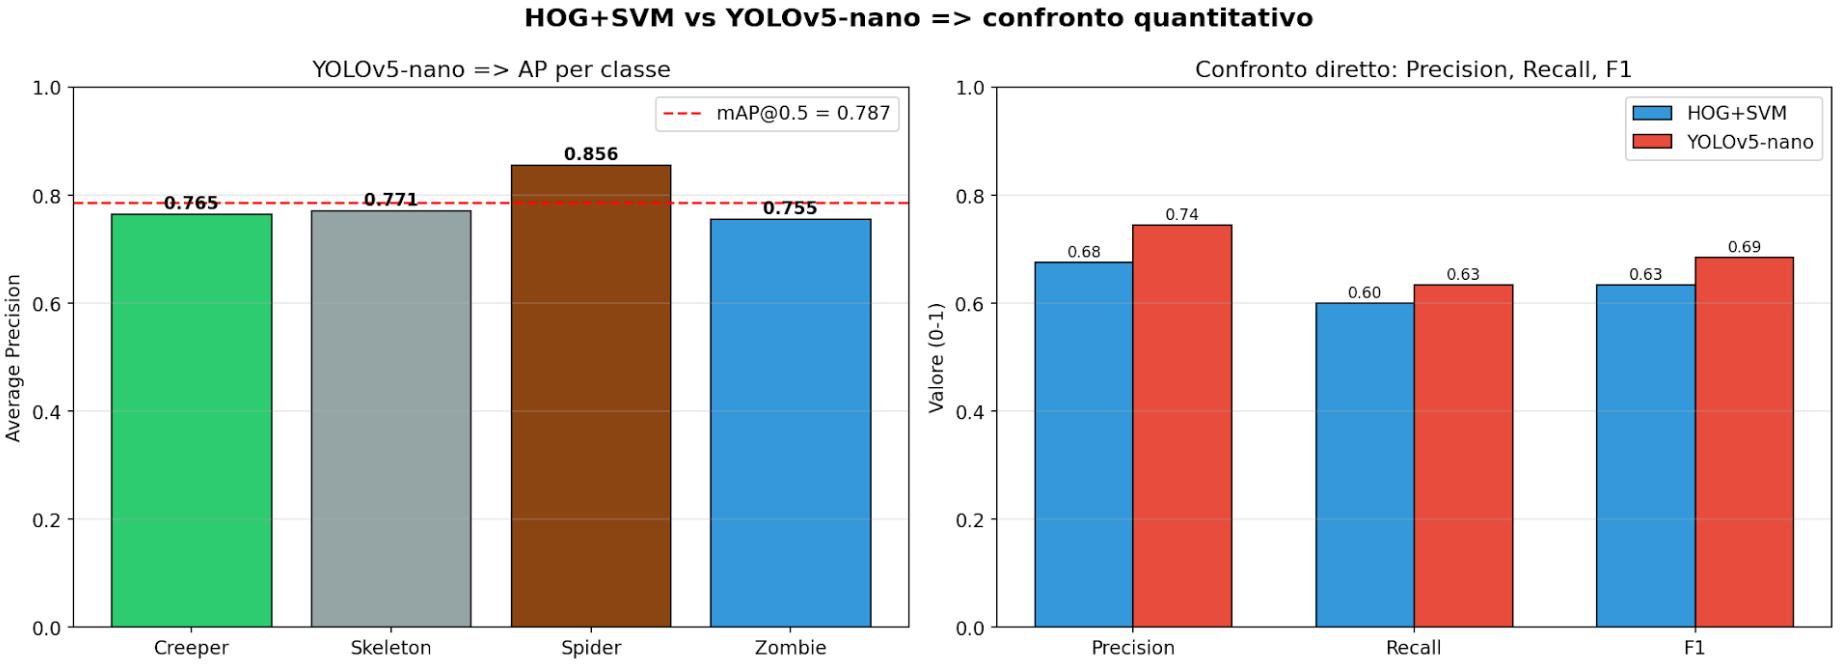


- YOLO batte HOG+SVM su tutte e tre le metriche dirette (Precision 0.745 vs 0.675, Recall 0.634 vs 0.600, F1 0.685 vs 0.634), ma il margine è più contenuto. Va ricordato però che il compito di YOLO è più difficile (deve anche localizzare, non solo classificare), quindi il divario reale a parità di compito è probabilmente maggiore di quello che questi numeri suggeriscono.
- Sul lato velocità il paragone numerico (1.4 ms/crop vs 138.3 ms/img) non è direttamente confrontabile, il primo è il tempo per classificare un singolo ritaglio già pronto, il secondo è il tempo per processare un'immagine intera. Se HOG+SVM dovesse fare detection completa (sliding window + image pyramid), il tempo salirebbe a secondi per immagine, quindi in un caso d'uso reale YOLO è nettamente più veloce, non più lento come suggerirebbe il confronto grezzo dei due numeri.

Sitesi?

YOLO è superiore sia in qualità che (nell'uso reale) in velocità; il vantaggio di HOG+SVM resta la leggerezza computazionale e il fatto di non richiedere GPU, non la precisione.